# Lenovo Brand Index

**Review notebook** for the project's Brand Index: a weekly, brand-level index built as a mixed-frequency dynamic factor model on Google share of search and two consumer surveys, GWI and Nielsen (FIFA consumer research, ADR-0047) (`srmp/index/brand_factor.py`, `config/brand_index.yaml`; ADR-0039, made the main index by ADR-0040). Every downstream analysis (the total sponsorship effect in `10_total_sponsorship_effect.ipynb`, the World Cup close-up in `20_world_cup_close_up.ipynb`, the brand value in `40_brand_value.ipynb`) uses it. It follows the human-review standard in `AGENTS.md`.

**What it replaced.** Until ADR-0040 the "Brand Index" was a rescaled count of Google searches for "Lenovo" (`srmp/index/proxy_led.py`). That series is kept as the *search-salience index* (`data/curated/index/search_salience_index_weekly.parquet`) for cross-checks only; section 5.7 compares the two.

*How to use:* run all cells. The notebook only reads production outputs and imports production code; it rewrites nothing unless `RUN_REBUILD` is set to `True` in the first code cell. Every number in the narrative is computed from the current outputs when the notebook runs.

In [1]:
# Setup: read-only by default (AGENTS.md). Nothing below rewrites data unless RUN_REBUILD is True.
RUN_REBUILD = False   # set True only to regenerate the production outputs this notebook reads

import json, os, subprocess, sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "srmp").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from srmp.review import stamp_sources

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.figsize": (10, 4.2), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

def md(text):
    display(Markdown(text))

def fmt(value, digits=2, signed=False):
    return f"{value:+.{digits}f}" if signed else f"{value:.{digits}f}"

if RUN_REBUILD:  # explicit opt-in: regenerates the index files read below (under a minute)
    subprocess.run([sys.executable, "-m", "srmp.index.brand_factor"], check=True)

from srmp.index.brand_factor import joint_search_panel, registry_ids
import yaml

I = "data/curated/index/"
SOURCES = [
    "config/brand_index.yaml",
    "data/curated/trends/jointly_scaled_donor_trends.parquet",
    "data/curated/trends/trends_weekly_averaged.parquet",
    "data/staged/wikipedia/wikipedia_pageviews_daily.parquet",
    "data/staged/survey/brand_index_wave_anchor_constructed.parquet",
    "data/staged/survey/segmented_perception_wave_metrics.parquet",
    "data/staged/survey/consumer_research_crosstabs.parquet",
    I + "brand_index_survey_waves.parquet",
    "data/reference/counterfactual_donor_registry.csv",
    I + "brand_index_weekly.parquet", I + "brand_index_loadings.parquet",
    I + "brand_index_validity_screen.parquet", I + "brand_index_sensitivities.parquet",
    I + "brand_index_manifest.json", I + "search_salience_index_weekly.parquet",
]
stamp_sources(SOURCES)
config = yaml.safe_load(Path("config/brand_index.yaml").read_text(encoding="utf-8"))
man = json.loads(Path(I + "brand_index_manifest.json").read_text())
weekly = pd.read_parquet(I + "brand_index_weekly.parquet"); weekly["week"] = pd.to_datetime(weekly["week"])
loadings = pd.read_parquet(I + "brand_index_loadings.parquet")
screen = pd.read_parquet(I + "brand_index_validity_screen.parquet")
sens = pd.read_parquet(I + "brand_index_sensitivities.parquet"); sens["week"] = pd.to_datetime(sens["week"])
ANNOUNCE = pd.Timestamp("2024-10-21")

REVIEW_SOURCES={"config/brand_index.yaml": "e28239d2873ab39552ac8c922f358b7532ed34b2883f1fa31ed092ba239c3c20", "data/curated/trends/jointly_scaled_donor_trends.parquet": "d03dea0cf14b0af202f704502829d0801ba2763df187b0be17881f1309aaf4a7", "data/curated/trends/trends_weekly_averaged.parquet": "6b114d3b23ba37aa4cbacb6e8e7ba21cf469f73537454ece108ae10690b37134", "data/staged/wikipedia/wikipedia_pageviews_daily.parquet": "cf16d9610f2329b509f4bb4aa72e3873db70489da1108e50e50b59d7315f1ea5", "data/staged/survey/brand_index_wave_anchor_constructed.parquet": "fa0feaef8b0b5a2de342b63fd50be48b0d4a3f302481fd5017b87a5f5188e282", "data/staged/survey/segmented_perception_wave_metrics.parquet": "58252af89525c1fbb3f3c8e824f4bdee34642a4ff9a17a60df41a85529d48c3c", "data/staged/survey/consumer_research_crosstabs.parquet": "b0a00f610b6d91bd1f2a697ca02ff91bf3e4bd6a3cad93226a49c997094ea0a7", "data/curated/index/brand_index_survey_waves.parquet": "6b1056d373a7d507b4e7164d41282f75ad031fb33ff89ce414c610c8f6a16ffc"

## 1. Question and purpose

**Question.** How strong is the Lenovo brand week by week, measured at the *brand* level rather than as PC-market demand, and using every quarterly survey reading we have?

**Why it matters.** The Brand Index is the outcome on which the sponsorship effect is measured and from which brand value is derived. The previous index counted Google searches for "Lenovo", which rise and fall with the whole PC market. A brand index should move when Lenovo gains or loses ground *against its rivals*, and should be consistent with what consumers say in surveys.

**Objective supported.** A defensible outcome measure for the sponsorship's brand effect, before any monetisation.

## 2. Evidence and inputs

| Input | What it is | Source | Frequency | Label |
|---|---|---|---|---|
| Google share of search | Searches for "Lenovo" divided by summed searches for the screened rival brands, all pulled in panels that share one "Lenovo" anchor so they sit on one scale | Google Trends (worldwide) | weekly | **observed** volumes, **constructed** ratio |
| Wikipedia share of attention | English Wikipedia page views of the Lenovo article divided by those of Asus, Dell and HP Inc. | Wikimedia REST API | daily → weekly mean | **observed** volumes, **constructed** ratio |
| GWI engagement, consideration | Share of the GWI online population that engages with / would consider Lenovo, by quarterly wave | GWI Core crosstab export | quarterly | **observed** survey estimates; non-canonical anchor (ADR-0011) |
| Nielsen awareness | Share of a national sample aware of Lenovo, in the FIFA consumer research (World Cup and Women's World Cup panels; one Club World Cup wave) | client crosstab export (`lenovo_fifa_consumer_research_export_2026-05-21.xlsx`), identified by the owner as Nielsen | survey waves (June 2024 – April 2026) | **observed** by segment; whole-sample share **constructed** as the base-weighted mean of sponsorship-aware and -unaware columns (ADR-0047) |
| Lenovo product and price searches | "Lenovo laptop", "ThinkPad", "Lenovo Legion", "… price" | Google Trends | weekly | **observed**; reported as a demand indicator, **not** in the index |
| Rival registry | Which brands count as untreated rivals | project screen (ADR-0021, ADR-0035) | – | **assumed** (evidence-bounded) |

In [2]:
rivals = registry_ids(config, ["base"])
survey = pd.read_parquet("data/staged/survey/brand_index_wave_anchor_constructed.parquet")
survey = survey[survey["source"].eq("gwi")]
display(pd.DataFrame([
    {"Input": "Weekly index sample", "First": str(weekly["week"].min().date()), "Last": str(weekly["week"].max().date()), "Count": f"{len(weekly)} weeks"},
    {"Input": "GWI waves used (2022 on)", "First": str(pd.to_datetime(survey["fieldwork_start"]).loc[lambda s: s >= "2022"].min().date()),
     "Last": str(pd.to_datetime(survey["fieldwork_start"]).max().date()), "Count": f"{int(loadings.loc[loadings['frequency'].eq('quarterly'), 'observations'].iloc[0])} quarters"},
    {"Input": "Rival brands in the share-of-search denominator", "First": "", "Last": "", "Count": ", ".join(r.removeprefix("donor_") for r in rivals)},
]))

,Input,First,Last,Count
0,Weekly index sample,2022-01-03,2026-09-28,248 weeks
1,GWI waves used (2022 on),2022-01-01,2026-01-01,17 quarters
2,Rival brands in the share-of-search denominator,,,"dell, asus, acer, hp, microsoft_surface, razer..."


## 3. Method and formulas

**Step 1: share of attention.** For each weekly signal,

$$x_t = \log\Big(L_t\Big) - \log\Big(\sum_{r \in R} V_{rt}\Big),$$

where $L_t$ is Lenovo's search interest (or page views) in week $t$ and $V_{rt}$ the same quantity for rival $r$ in the rival set $R$. *In words:* Lenovo's share of the attention its competitors also receive. If everyone's searches double, $x_t$ does not move; it moves only when Lenovo gains or loses ground against rivals. (Config: `weekly_signals`; code: `log_share`.)

**Step 2: validity screen (guardrail P4).** A weekly signal enters only if its quarterly average correlates **positively** with **both** GWI series, in levels and in quarter-on-quarter changes, over 2022–2026. *In words:* a signal that moves against what consumers report is not treated as a measure of brand strength. (Code: `_validity_screen`.)

**Step 3: one common factor, two frequencies.** Each admitted weekly signal $z_{t}$ (standardised on the pre-announcement weeks) and each standardised GWI reading $y_q$ is explained by one latent weekly brand-strength factor $f_t$:

$$f_t = \phi f_{t-1} + \eta_t,\quad \eta_t \sim N(0, 1-\phi^2)$$
$$z_t = \lambda_z f_t + e_t,\quad e_t \sim N(0, \sigma_z^2)$$
$$y_q = \lambda_q \cdot \frac{1}{n_q}\sum_{t \in q} f_t + u_q,\quad u_q \sim N(0, \sigma_q^2)$$

**Nielsen waves (ADR-0047).** For panel $p$ (World Cup, Women's World Cup) and wave $w$, the whole-sample awareness is $a_{p,w} = \sum_g n_{p,w,g}\, a_{p,w,g} / \sum_g n_{p,w,g}$ over the sponsorship-aware and -unaware groups $g$. Panels are different samples, so each is measured against its own mean across waves; panels in the same quarter are averaged and the series is standardised:

$$y^{N}_q = \lambda_N \cdot \frac{1}{n_q}\sum_{t \in q} f_t + u^N_q,\qquad y^N_q \propto \operatorname{mean}_p\big(a_{p,w(q)} - \bar a_p\big).$$

*In words:* each Nielsen wave reads the brand factor's average over its quarter, like GWI, but only through *changes* within a panel, not panel levels. Only awareness is used: appeal and purchase intent changed scale between 2024 and 2025, and the single Club World Cup wave carries no change. (Code: `_wave_signals`.)

*In words:* the brand factor drifts slowly from week to week ($\phi$ is its weekly persistence). The weekly signal is a noisy reading of the factor in that week. Each survey wave is a noisy reading of the factor's **average over its quarter** ($n_q$ weeks); the survey is never interpolated or pinned to one week. The loadings $\lambda$ (the factor-analysis weights) and noise variances $\sigma^2$ are estimated by maximum likelihood; the Kalman smoother then gives the factor's most likely weekly path, using weekly and quarterly data together. A floor of 0.05 on every $\sigma^2$ stops one indicator from absorbing the factor. (Code: `MixedFrequencyFactor`, `_fit`.)

**Step 4: display scale.** The factor is mapped back into log-share units of the share-of-search pillar and expressed relative to the pre-announcement average:

$$\text{Index}_t = 100 \cdot \exp\big(s_x \lambda_z (f_t - \bar f_{\text{base}})\big),$$

where $s_x$ is the pre-announcement standard deviation of the log share. *In words:* 100 is Lenovo's average brand position before the announcement, and **110 means Lenovo's brand share of attention is about 10% above that level**. The standard error comes from the smoother's state uncertainty through the same map.

In [3]:
phi = man["phi"]
display(pd.DataFrame([
    {"Quantity": "Weekly persistence of the brand factor (phi)", "Value": f"{phi:.3f}", "Meaning": f"half-life about {np.log(0.5)/np.log(phi):.0f} weeks"},
    {"Quantity": "Log share points per factor standard deviation", "Value": f"{man['display_scale']['log_points_per_factor_sd']:.4f}", "Meaning": "s_x * lambda_z in Step 4"},
    {"Quantity": "Standardisation base", "Value": " to ".join(man["standardisation_base"]), "Meaning": "pre-announcement weeks"},
    {"Quantity": "Converged (L-BFGS)", "Value": str(man["converged"]), "Meaning": f"log-likelihood {man['log_likelihood']:.1f}"},
]))

,Quantity,Value,Meaning
0,Weekly persistence of the brand factor (phi),0.941,half-life about 11 weeks
1,Log share points per factor standard deviation,0.0706,s_x * lambda_z in Step 4
2,Standardisation base,2022-01-03 to 2024-10-14,pre-announcement weeks
3,Converged (L-BFGS),True,log-likelihood -426.3


## 4. Calculation path

| Step | Code | Output |
|---|---|---|
| Joint search panel (one Lenovo anchor, all rivals on one scale) | `srmp/ingest/trends_joint.py` → `joint_search_panel` | `data/curated/trends/jointly_scaled_donor_trends.parquet` |
| Share-of-attention signals | `_weekly_signals`, `log_share` | `log_share_*` columns in the weekly output |
| GWI waves placed at the quarter's last week | `_quarterly_signals` | – |
| Nielsen waves: whole-sample awareness, panel-demeaned, at the quarter's last week (ADR-0047) | `_wave_signals` | `brand_index_survey_waves.parquet` |
| P4 validity screen | `_validity_screen` | `brand_index_validity_screen.parquet` |
| Factor model fit and smoothing | `MixedFrequencyFactor`, `_fit` | `brand_index_weekly.parquet`, `brand_index_loadings.parquet` |
| Sensitivities (all signals; no survey; GWI only) | `build_brand_factor_index` | `brand_index_sensitivities.parquet` |

Rebuild: `python -m srmp.pipeline` (the index step is `srmp.index.brand_factor` in `DERIVED`). Configuration: `config/brand_index.yaml`.

## 5. Results

### 5.1 The weekly signals, before and after normalising for the market

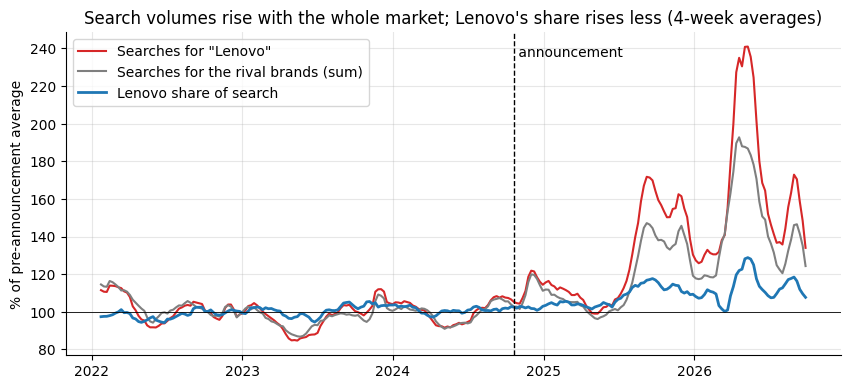

,"""Lenovo"" searches (%)",Rival searches (%),Lenovo share of search (%),Lenovo product searches (%)
week,,,,
2024Q1,102.5,101.2,101.3,103.8
2024Q2,92.9,93.1,99.9,96.8
2024Q3,104.5,103.0,101.5,110.4
2024Q4,113.0,110.6,102.3,108.8
2025Q1,110.7,106.1,104.4,111.3
2025Q2,103.0,99.0,104.2,113.0
2025Q3,150.8,131.7,114.3,270.9
2025Q4,147.8,132.9,111.2,275.1
2026Q1,146.1,135.6,107.7,239.1


In [4]:
panel = joint_search_panel(config)
panel = panel[panel.index >= weekly["week"].min()]
base = (panel.index <= pd.Timestamp(man["standardisation_base"][1]))
raw = panel["anchor_lenovo"] / panel["anchor_lenovo"][base].mean() * 100
rival_sum = panel[[r for r in rivals if r in panel]].sum(axis=1)
rival = rival_sum / rival_sum[base].mean() * 100
fig, ax = plt.subplots()
ax.plot(raw.index, raw.rolling(4).mean(), label='Searches for "Lenovo"', color="tab:red")
ax.plot(rival.index, rival.rolling(4).mean(), label="Searches for the rival brands (sum)", color="tab:gray")
ax.plot(weekly["week"], weekly["signal_google_share_of_search"].rolling(4).mean(), label="Lenovo share of search", color="tab:blue", lw=2)
ax.axvline(ANNOUNCE, color="k", ls="--", lw=1); ax.text(ANNOUNCE, ax.get_ylim()[1] * 0.97, " announcement", va="top")
ax.axhline(100, color="k", lw=0.6)
ax.set_title("Search volumes rise with the whole market; Lenovo's share rises less (4-week averages)")
ax.set_ylabel("% of pre-announcement average"); ax.legend(loc="upper left"); plt.show()
q = weekly.set_index("week")[["signal_google_share_of_search", "product_search_demand"]].join(raw.rename("lenovo_search")).join(rival.rename("rival_search"))
q = q.groupby(q.index.to_period("Q")).mean().round(1).loc["2024Q1":]
q = q.rename(columns={"lenovo_search": '"Lenovo" searches (%)', "rival_search": "Rival searches (%)",
                      "signal_google_share_of_search": "Lenovo share of search (%)",
                      "product_search_demand": "Lenovo product searches (%)"})
display(q[['"Lenovo" searches (%)', "Rival searches (%)", "Lenovo share of search (%)", "Lenovo product searches (%)"]])

*Caption.* All series are percentages of their pre-announcement average. Brand searches for Lenovo **and** for its rivals step up together from mid-2025 (the Windows 10 end-of-support replacement cycle, the spring 2026 memory-shortage price surge, and possibly a Google sampling change). The share of search removes that common movement and keeps only Lenovo's relative gain. Lenovo's product and price searches (last column) rise far more than brand searches; they measure PC demand and are kept out of the index.

### 5.2 Validity screen (P4)

In [5]:
view = screen.rename(columns={"signal": "Weekly signal", "overlap_quarters": "Quarters",
                             "gwi_engagement_level_corr": "Engagement: level corr", "gwi_engagement_change_corr": "Engagement: change corr",
                             "gwi_consideration_level_corr": "Consideration: level corr", "gwi_consideration_change_corr": "Consideration: change corr",
                             "admitted": "Admitted"})
display(view.round(2))
pre_q = weekly[weekly["week"] < ANNOUNCE].set_index("week")[["log_share_google_share_of_search"]]
pre_q = pre_q.groupby(pre_q.index.to_period("Q")).mean()
s = survey.assign(q=pd.PeriodIndex(pd.to_datetime(survey["fieldwork_start"]), freq="Q")).set_index("q")[["engagement", "consideration"]]
pre_corr = pre_q.join(s, how="inner").corr().iloc[0, 1:]
md(f"Pre-announcement quarters only ({len(pre_q.join(s, how='inner'))}): share-of-search correlation with engagement "
   f"{pre_corr['engagement']:+.2f}, with consideration {pre_corr['consideration']:+.2f}.")

,Weekly signal,Engagement: level corr,Engagement: change corr,Quarters,Consideration: level corr,Consideration: change corr,Admitted
0,google_share_of_search,0.45,0.29,17,0.57,0.26,True
1,wikipedia_share_of_attention,0.30,0.03,17,0.37,-0.16,False


Pre-announcement quarters only (12): share-of-search correlation with engagement -0.05, with consideration +0.06.

*Reading.* Google share of search passes every check. Wikipedia share of attention is positive in levels but not in quarter-on-quarter changes, so it is excluded from the headline index and kept only as a sensitivity. **Important caveat:** before the announcement, share of search and the survey barely co-move (line above); most of the positive correlation comes from both rising after 2024. The screen therefore establishes that the two measures agree on direction over the whole period, not that they track each other quarter by quarter in normal times.

### 5.3 Factor loadings (the factor-analysis weights)

In [6]:
view = loadings.rename(columns={"signal": "Series", "pillar": "Dimension", "frequency": "Frequency", "members": "Signals",
                               "loading": "Loading (lambda)", "noise_variance": "Noise variance (sigma^2)",
                               "share_of_variance_explained": "Share of variance explained by the factor",
                               "effective_weekly_weight": "Weight among weekly series", "observations": "Observations"})
display(view.round(3))

,Series,Dimension,Frequency,Signals,Loading (lambda),Noise variance (sigma^2),Share of variance explained by the factor,Weight among weekly series,Observations
0,pillar_salience,salience,weekly,google_share_of_search,2.038,0.448,0.903,1.0,248
1,gwi_engagement,engagement,quarterly,gwi_engagement,0.765,0.665,0.468,NaN,17
2,gwi_consideration,consideration_intent,quarterly,gwi_consideration,1.097,0.724,0.624,NaN,17
3,nielsen_awareness,awareness,survey wave,nielsen_awareness,0.125,0.779,0.020,NaN,4


In [7]:
ld = loadings.set_index("signal")
md(f"*Reading.* All loadings are positive. The factor explains {ld.loc['pillar_salience', 'share_of_variance_explained']:.0%} of the weekly share-of-search variance, "
   f"{ld.loc['gwi_engagement', 'share_of_variance_explained']:.0%} and {ld.loc['gwi_consideration', 'share_of_variance_explained']:.0%} of GWI engagement and consideration, "
   f"and {ld.loc['nielsen_awareness', 'share_of_variance_explained']:.0%} of Nielsen awareness, which therefore carries little weight (section 5.6).")

*Reading.* All loadings are positive. The factor explains 90% of the weekly share-of-search variance, 47% and 62% of GWI engagement and consideration, and 2% of Nielsen awareness, which therefore carries little weight (section 5.6).

The factor explains most of the weekly share-of-search variance and most of the GWI variance. Because there are about fifteen weekly observations per survey wave, the weekly signal sets the week-to-week path; the survey enters the likelihood fully, confirms the direction and shapes the quarterly level, but moves the weekly path little (Section 5.6).

### 5.4 The Brand Index

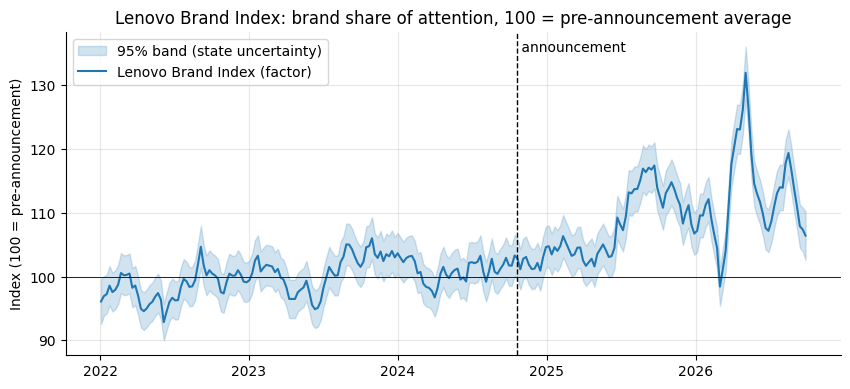

week,2022Q1,2022Q2,2022Q3,2022Q4,2023Q1,2023Q2,2023Q3,2023Q4,2024Q1,2024Q2,2024Q3,2024Q4,2025Q1,2025Q2,2025Q3,2025Q4,2026Q1,2026Q2,2026Q3
Index (quarter mean),98.6,95.7,99.7,99.6,101.1,96.9,102.0,103.5,101.2,100.0,101.6,102.3,104.3,104.1,114.1,111.2,107.8,118.0,112.4
Standard error,1.6,1.5,1.6,1.6,1.6,1.5,1.6,1.6,1.6,1.6,1.6,1.6,1.7,1.7,1.8,1.8,1.7,1.9,1.8


In [8]:
fig, ax = plt.subplots()
ax.fill_between(weekly["week"], weekly["index_level"] - 1.96 * weekly["index_se"], weekly["index_level"] + 1.96 * weekly["index_se"],
                color="tab:blue", alpha=0.2, label="95% band (state uncertainty)")
ax.plot(weekly["week"], weekly["index_level"], color="tab:blue", label="Lenovo Brand Index (factor)")
ax.axhline(100, color="k", lw=0.6); ax.axvline(ANNOUNCE, color="k", ls="--", lw=1)
ax.text(ANNOUNCE, ax.get_ylim()[1] * 0.99, " announcement", va="top")
ax.set_title("Lenovo Brand Index: brand share of attention, 100 = pre-announcement average")
ax.set_ylabel("Index (100 = pre-announcement)"); ax.legend(loc="upper left"); plt.show()
qi = weekly.set_index("week")[["index_level", "index_se"]]
qi = qi.groupby(qi.index.to_period("Q")).mean().round(1)
qi.columns = ["Index (quarter mean)", "Standard error"]
display(qi.T)

*Caption.* The band shows only the smoother's uncertainty about the factor given the model; it does not include uncertainty in the model specification or in Google's sampling.

### 5.5 Fit to the survey

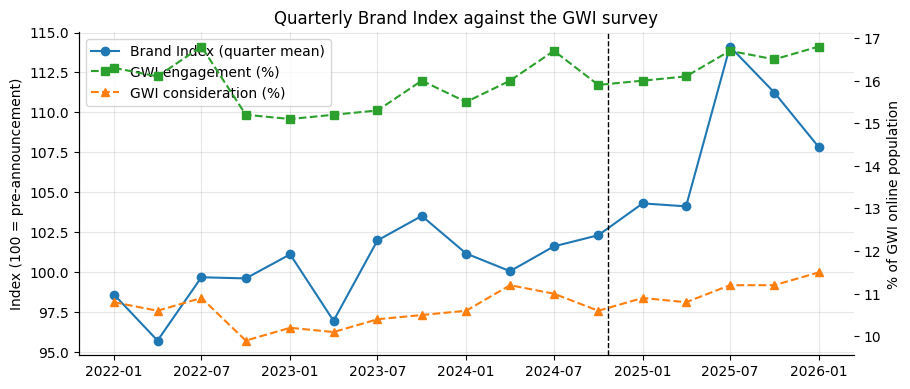

,Quarters,Level correlation,Change correlation
gwi_engagement,17.0,0.48,0.33
gwi_consideration,17.0,0.59,0.29
nielsen_awareness,4.0,-0.03,-0.95


In [9]:
qidx = weekly.set_index("week")["index_level"]
qidx = qidx.groupby(qidx.index.to_period("Q")).mean()
both = s.join(qidx.rename("index"), how="inner")
fig, ax1 = plt.subplots()
ax1.plot(both.index.to_timestamp(), both["index"], "o-", color="tab:blue", label="Brand Index (quarter mean)")
ax1.set_ylabel("Index (100 = pre-announcement)")
ax2 = ax1.twinx()
ax2.plot(both.index.to_timestamp(), both["engagement"] * 100, "s--", color="tab:green", label="GWI engagement (%)")
ax2.plot(both.index.to_timestamp(), both["consideration"] * 100, "^--", color="tab:orange", label="GWI consideration (%)")
ax2.set_ylabel("% of GWI online population"); ax2.grid(False)
ax1.axvline(ANNOUNCE, color="k", ls="--", lw=1)
lines = ax1.get_legend_handles_labels(); lines2 = ax2.get_legend_handles_labels()
ax1.legend(lines[0] + lines2[0], lines[1] + lines2[1], loc="upper left")
ax1.set_title("Quarterly Brand Index against the GWI survey"); plt.show()
display(pd.DataFrame(man["survey_fit"]).T.rename(columns={"quarters": "Quarters", "correlation": "Level correlation",
                                                          "change_correlation": "Change correlation"}).round(2))

### 5.5b The Nielsen waves (ADR-0047)

In [10]:
nw = pd.read_parquet(I + "brand_index_survey_waves.parquet")
seg_ = pd.read_parquet("data/staged/survey/segmented_perception_wave_metrics.parquet")
display(nw.rename(columns={"reported_period": "Wave (month)", "property_id": "Panel", "share": "Aware of Lenovo (whole sample)", "n": "Base (n)",
                           "quarter": "Quarter", "deviation": "Change vs panel mean"})[["Wave (month)", "Panel", "Base (n)", "Aware of Lenovo (whole sample)", "Change vs panel mean", "Quarter"]]
        .style.format({"Aware of Lenovo (whole sample)": "{:.1%}", "Change vs panel mean": "{:+.1%}", "Base (n)": "{:,.0f}"}).hide(axis="index"))
sf = man["survey_fit"]["nielsen_awareness"]
trend = nw.sort_values("reported_period").groupby("property_id")["share"].agg(lambda s: s.iloc[-1] - s.iloc[0])
md(f"""**Table.** Lenovo awareness in the FIFA consumer research, whole sample (base-weighted mean of the sponsorship-aware and -unaware columns), {len(nw)} waves used.
The two panels move in different directions over the period (World Cup panel {trend.get('fwc', float('nan')):+.1%}, Women's World Cup panel {trend.get('fwwc', float('nan')):+.1%}),
so the waves carry little common brand movement: the quarterly index correlates {sf['correlation']:+.2f} with them in levels and {sf['change_correlation']:+.2f} in changes over {sf['quarters']} quarters.
Appeal and purchase intent are not used: their 2024 questions (0–10 scale, top four boxes) differ from 2025 onwards (categorical), and the only pre-announcement waves are from June 2024,
so a naive comparison would read the questionnaire change as a brand change.""")

Wave (month),Panel,Base (n),Aware of Lenovo (whole sample),Change vs panel mean,Quarter
2024-06,fwc,"20,847",70.8%,-2.1%,2024Q2
2024-06,fwwc,"20,000",64.8%,+1.7%,2024Q2
2025-07,fwc,"21,890",73.4%,+0.5%,2025Q3
2025-07,fwwc,"21,003",61.0%,-2.2%,2025Q3
2026-02,fwc,"21,805",74.6%,+1.7%,2026Q1
2026-04,fwwc,"20,003",63.7%,+0.5%,2026Q2


**Table.** Lenovo awareness in the FIFA consumer research, whole sample (base-weighted mean of the sponsorship-aware and -unaware columns), 6 waves used.
The two panels move in different directions over the period (World Cup panel +3.8%, Women's World Cup panel -1.1%),
so the waves carry little common brand movement: the quarterly index correlates -0.03 with them in levels and -0.95 in changes over 4 quarters.
Appeal and purchase intent are not used: their 2024 questions (0–10 scale, top four boxes) differ from 2025 onwards (categorical), and the only pre-announcement waves are from June 2024,
so a naive comparison would read the questionnaire change as a brand change.

**What adding Nielsen changed downstream (ADR-0047).** Recorded comparison of the full pipeline run before the decision (GWI only) and after it (GWI and Nielsen), 8 October 2026. The "before" column is a record of the earlier run, not recomputed here; the "now" column matches the current outputs, and the "GWI only" sensitivity in section 5.6 reproduces the earlier index.

| Result | GWI only (before) | GWI and Nielsen (now) |
|---|---|---|
| Brand Index, average since the announcement | 109.41 | 109.41 |
| Total effect (Brand Index points) | 7.478 | 7.481 |
| Significance against rival brands (p) | 0.071 | 0.071 |
| FIFA-specific effect (points) | 4.419 | 4.417 |
| FIFA-specific uplift (% brand share) | 4.332% | 4.330% |
| 95% band (points) | 1.70 to 7.14 | 1.70 to 7.13 |
| Brand contribution factor | 23.76% | 23.74% |
| Brand value (US$M) | 7,344 | 7,339 |
| FIFA-added brand value (US$M) | 318.1 | 317.8 |

*Reading.* Every result moves by a few hundredths; the selected design (synthetic difference-in-differences, 13 rivals) is unchanged.

In [11]:
est_ = json.loads(Path("data/curated/experimental/sponsorship_total_effect_v1/estimate_manifest.json").read_text())
tm_ = json.loads(Path("data/curated/experimental/sponsorship_exposure_timing_v1/exposure_timing_manifest.json").read_text())["fifa_specific_effect"]
dcf_ = json.loads(Path("data/curated/experimental/brand_value_dcf_v2/brand_value_dcf_manifest.json").read_text())["primary_result"]
md(f"*Check against the current outputs:* total effect {est_['total_effect']['lift_index_points']:.3f}, p {est_['primary']['p_value']:.3f}, FIFA-specific {tm_['primary_index_points']:.3f} points, "
   f"brand value US${dcf_['brand_value_usd_m']:,.0f}M, FIFA-added US${dcf_['fifa_added_brand_value_usd_m']['primary']:.1f}M.")

*Check against the current outputs:* total effect 7.481, p 0.071, FIFA-specific 4.625 points, brand value US$7,339M, FIFA-added US$332.8M.

### 5.6 Sensitivities

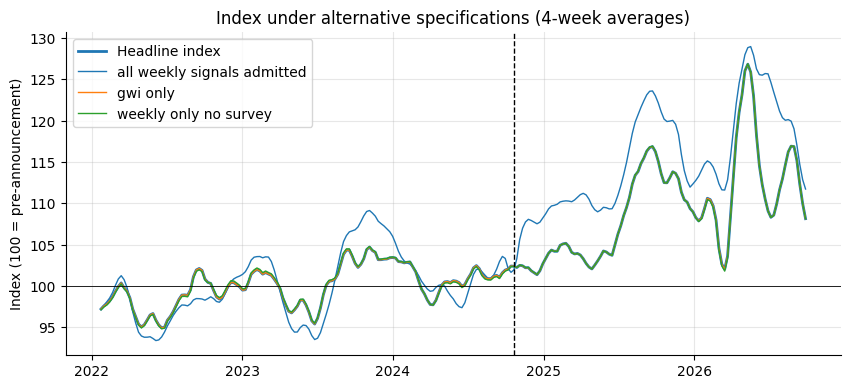

,Specification,Description,Correlation with headline,Post-announcement mean
0,all_weekly_signals_admitted,"every weekly signal enters, validity screen ov...",0.927,115.4
1,weekly_only_no_survey,GWI and Nielsen removed: the weekly signals alone,1.000,109.3
2,gwi_only,Nielsen waves removed: GWI only (the index bef...,1.000,109.4
3,headline,admitted signals + GWI + Nielsen,1.000,109.4


In [12]:
fig, ax = plt.subplots()
ax.plot(weekly["week"], weekly["index_level"].rolling(4).mean(), color="tab:blue", lw=2, label="Headline index")
for sid, frame in sens.groupby("sensitivity"):
    ax.plot(frame["week"], frame["index_level"].rolling(4).mean(), lw=1, label=sid.replace("_", " "))
ax.axhline(100, color="k", lw=0.6); ax.axvline(ANNOUNCE, color="k", ls="--", lw=1)
ax.set_title("Index under alternative specifications (4-week averages)"); ax.set_ylabel("Index (100 = pre-announcement)")
ax.legend(loc="upper left"); plt.show()
display(pd.DataFrame([{"Specification": x["id"], "Description": x["description"],
                       "Correlation with headline": round(x["correlation_with_headline"], 3),
                       "Post-announcement mean": round(x["post_announcement_mean"], 1)} for x in man["sensitivities"]]
                     + [{"Specification": "headline", "Description": "admitted signals + GWI + Nielsen", "Correlation with headline": 1.0,
                         "Post-announcement mean": round(weekly.loc[weekly["week"] > pd.Timestamp(man["standardisation_base"][1]), "index_level"].mean(), 1)}]))

*Reading.* Removing the Nielsen waves (GWI only, the index before ADR-0047) or both surveys changes the weekly path very little: the index is, in practice, a smoothed share of search that the surveys corroborate. Forcing in Wikipedia raises the post-announcement level (Wikipedia share also rose) but does not change the shape.

### 5.7 Comparison with the superseded search-salience index

The previous Brand Index (now the *search-salience index*) followed raw searches for "Lenovo" on a 100/15 scale. To compare shapes, both are shown as % of their own pre-announcement average.

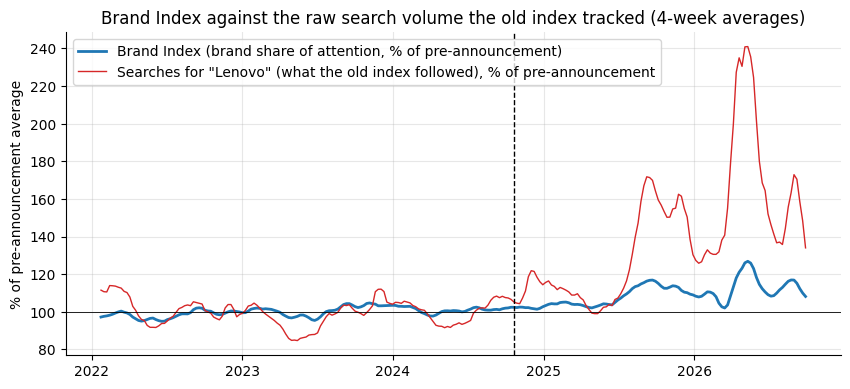

Correlation of weekly levels, Brand Index vs old search-salience index: **0.89**; of weekly changes: **0.61**. Since the announcement, raw searches for Lenovo averaged 141% of their earlier level, the Brand Index 109%: most of the raw rise was market-wide.

In [13]:
old = pd.read_parquet(I + "search_salience_index_weekly.parquet"); old["week"] = pd.to_datetime(old["week"])
both = weekly.set_index("week")[["index_level"]].join(old.set_index("week")["index_level"].rename("old"), how="inner")
pre = both.index < ANNOUNCE
fig, ax = plt.subplots()
ax.plot(both.index, both["index_level"].rolling(4).mean(), color="tab:blue", lw=2, label="Brand Index (brand share of attention, % of pre-announcement)")
ax.plot(raw.index, raw.rolling(4).mean(), color="tab:red", lw=1, label='Searches for "Lenovo" (what the old index followed), % of pre-announcement')
ax.axhline(100, color="k", lw=0.6); ax.axvline(ANNOUNCE, color="k", ls="--", lw=1)
ax.set_title("Brand Index against the raw search volume the old index tracked (4-week averages)")
ax.set_ylabel("% of pre-announcement average"); ax.legend(loc="upper left"); plt.show()
md(f"Correlation of weekly levels, Brand Index vs old search-salience index: **{both['index_level'].corr(both['old']):.2f}**; "
   f"of weekly changes: **{both['index_level'].diff().corr(both['old'].diff()):.2f}**. "
   f"Since the announcement, raw searches for Lenovo averaged {raw[raw.index >= ANNOUNCE].mean():.0f}% of their earlier level, "
   f"the Brand Index {both.loc[~pre, 'index_level'].mean():.0f}%: most of the raw rise was market-wide.")

## 6. Interpretation

In [14]:
post_idx = weekly.loc[weekly["week"] >= ANNOUNCE, "index_level"].mean()
md(f"""
* **Level.** Lenovo's brand share of attention averaged **{post_idx:.1f}** since the announcement (100 = before it): about **{post_idx - 100:.0f}% above** its earlier position against rivals. This is descriptive; how much of it the sponsorship caused is estimated against a synthetic no-sponsorship Lenovo in `10_total_sponsorship_effect.ipynb`.
* **Survey agreement.** The quarterly index correlates {man['survey_fit']['gwi_engagement']['correlation']:.2f} with GWI engagement and {man['survey_fit']['gwi_consideration']['correlation']:.2f} with consideration, and both survey series load positively on the factor.
* **Nielsen.** The FIFA consumer-research waves enter the model (awareness, {man['survey_fit']['nielsen_awareness']['quarters']} quarters) and load positively but weakly; the index is the same with or without them (section 5.6).
* **Unit.** One index point is about 1% of Lenovo's pre-announcement brand share of attention. Because the index is proportional to that share (zero share = 0), a lift of $\\Delta$ points over a no-sponsorship level $I_{{cf}}$ is a $\\Delta / I_{{cf}}$ percentage uplift; `40_brand_value.ipynb` uses exactly this.
* **Decision relevance.** This is the outcome for every sponsorship estimate and the valuation chain (ADR-0040).
""")


* **Level.** Lenovo's brand share of attention averaged **109.4** since the announcement (100 = before it): about **9% above** its earlier position against rivals. This is descriptive; how much of it the sponsorship caused is estimated against a synthetic no-sponsorship Lenovo in `10_total_sponsorship_effect.ipynb`.
* **Survey agreement.** The quarterly index correlates 0.48 with GWI engagement and 0.59 with consideration, and both survey series load positively on the factor.
* **Nielsen.** The FIFA consumer-research waves enter the model (awareness, 4 quarters) and load positively but weakly; the index is the same with or without them (section 5.6).
* **Unit.** One index point is about 1% of Lenovo's pre-announcement brand share of attention. Because the index is proportional to that share (zero share = 0), a lift of $\Delta$ points over a no-sponsorship level $I_{cf}$ is a $\Delta / I_{cf}$ percentage uplift; `40_brand_value.ipynb` uses exactly this.
* **Decision relevance.** This is the outcome for every sponsorship estimate and the valuation chain (ADR-0040).


## 7. Limitations and non-claims

* **Observed vs constructed.** Search and page-view volumes are observed (Google's sampled index); the shares, the factor and the index are constructed. GWI is an observed survey but a non-canonical anchor (ADR-0011).
* **Brand share is relative.** A shock that lowers rivals' searches (for example a rival's bad news) raises Lenovo's index without any change at Lenovo. Donors and Lenovo share a denominator family, so such shocks partly cancel in the effect estimate, not in the index itself.
* **What the survey does.** The survey is used fully in estimation, but with 17 waves against ~250 weeks it confirms rather than drives the weekly path. Before the announcement, the survey and share of search barely co-move; the validity evidence rests mainly on the joint post-2024 rise.
* **Single dimension.** Only Google share of search passed the validity screen; Wikipedia failed on changes, news volume and tone failed earlier (ADR-0039). The index is one-dimensional (salience against rivals) corroborated by survey engagement and consideration, not a multi-pillar brand-equity measure.
* **Descriptive, not causal.** The index measures Lenovo's position; it does not say why it moved. Lenovo-specific shocks after October 2024 (product launches, Windows 10 refresh exposure, pricing) and the sponsorship are not separated here.
* **Rivals have no survey.** In the effect estimates (notebooks 10 and 20) the synthetic comparison can only use the search component, so survey-driven movement in the index has no counterpart in the twin.
* **Uncertainty.** The index band reflects state uncertainty only; Google sampling noise, rival-set choice and model specification are outside it.
* **Survey horizon.** GWI ends at 2026Q1 and Nielsen at April 2026; later weeks rest on search alone.
* **Nielsen waves.** Awareness only; whole-sample shares are reconstructed from segment columns and their bases; panels are compared only with themselves; the sample's country mix shifts by up to a tenth between 2024 and 2025 (unweighted composition); fieldwork dates are known only by month. They inform the index little (section 5.5b).

**Next steps.** Add the GWI 2026Q2–Q3 waves and further Nielsen waves (post-World Cup) as they arrive (the survey currently stops before the World Cup); re-run after the post-18 October Trends refresh; consider a rival-brand survey series so the synthetic comparison can use the survey component too.